In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [2]:
data = pd.read_csv(r'D:\Learnbay\Weekend Project Sunduram sir\INSURANCE PREMIUM PREDICTION\insurance.csv')
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## Missing Value

In [5]:
data.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

## Understand categorical column

In [6]:
for col in data.select_dtypes('O'):
    print(col ,':',data[col].unique())

sex : ['female' 'male']
smoker : ['yes' 'no']
region : ['southwest' 'southeast' 'northwest' 'northeast']


## Encode the categorical column

In [7]:
data['smoker'] = data['smoker'].map({'yes':1, 'no':0})
data['sex'] = data['sex'].map({'male':1, 'female':0})

In [8]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,southwest,16884.92400
1,18,1,33.770,1,0,southeast,1725.55230
2,28,1,33.000,3,0,southeast,4449.46200
3,33,1,22.705,0,0,northwest,21984.47061
4,32,1,28.880,0,0,northwest,3866.85520


## Correlation of columns with charges (target)

In [9]:
data.corr(numeric_only=True)['charges'].sort_values()

sex         0.057292
children    0.067998
bmi         0.198341
age         0.299008
smoker      0.787251
charges     1.000000
Name: charges, dtype: float64

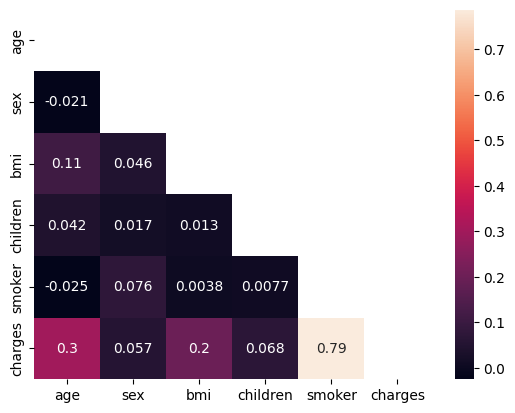

In [10]:
corr = data.corr(numeric_only=True)
sns.heatmap(corr , annot=True , mask=np.triu(corr))
plt.show()

### Observation 
* there is a strong correlation for patient who are smokers

## Understand target variable

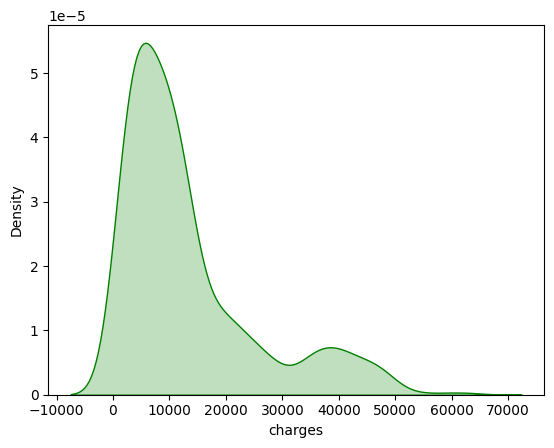

In [11]:
sns.kdeplot(data['charges'] , fill=True ,color='green')
plt.show()

In [12]:
data['charges'].skew()

1.5158796580240388

## Outlier plot for target 

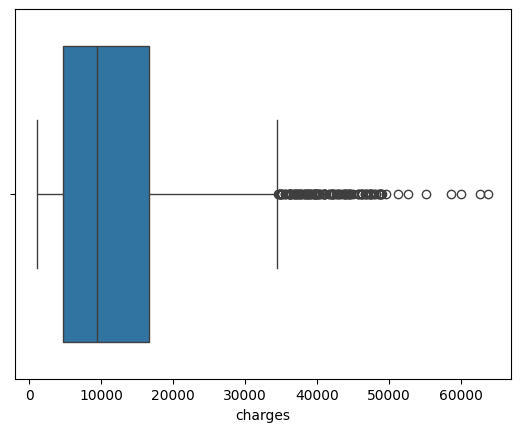

In [13]:
sns.boxplot(data['charges'] , orient='h')
plt.show()

### Observation 
* outlier is present in charges (target) column
* Yes, you can (and often should) use outlier treatment in regression problems when the target variable (dependent variable) contains outliers. However, whether and how to treat them depends on the context of the problem and business goals.
*  Why treat outliers in the target variable?
    * Outliers in the target (y) can:
        * Distort model performance, especially for algorithms like Linear Regression, which are sensitive to extreme values.
        * Increase error metrics like RMSE or MAE.

        * Cause the model to overfit, trying too hard to predict rare values.

        * Reduce generalization on unseen data.

* Box-Cox transformation because our data is skewed or has multiplicative outliers


## Bivariate analysis & Multivariate analysis

### Distrubution of charges for smokers and non-smokers

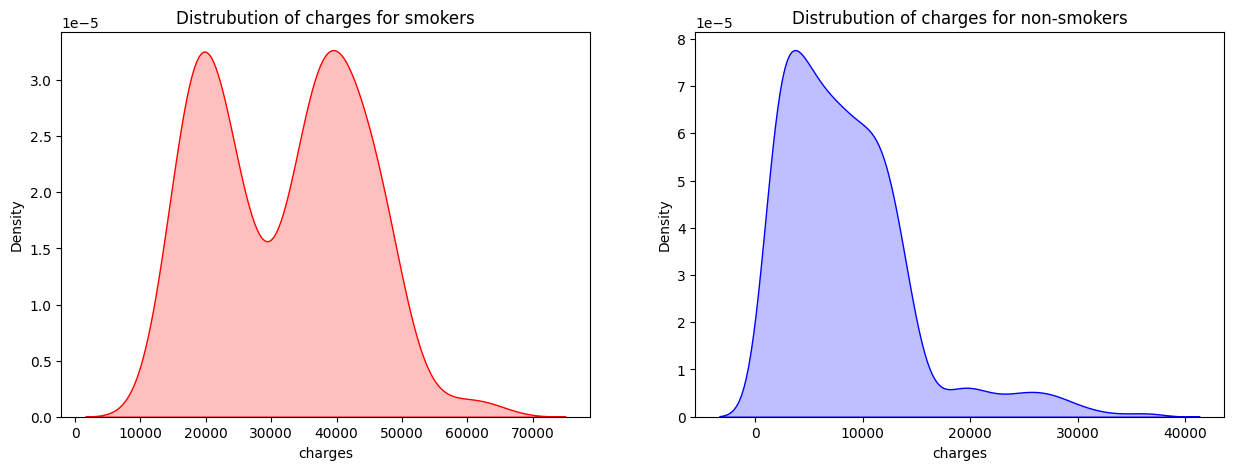

In [14]:
fig = plt.figure(figsize=(15,5))
ax = fig.add_subplot(121)
sns.kdeplot(data[data['smoker']== 1]['charges'] , color='red' , fill=True , ax=ax)
ax.set_title('Distrubution of charges for smokers')

ax = fig.add_subplot(122)
sns.kdeplot(data[data['smoker']== 0]['charges'] , color='blue' , fill=True , ax=ax)
ax.set_title('Distrubution of charges for non-smokers')
plt.show()

#### Observation 
* non-smoker charges is low compare to smokers
* smoking patient tends to spend more on treatement (charges)

### Count of smokers and non-smokers with respective gender (sex)

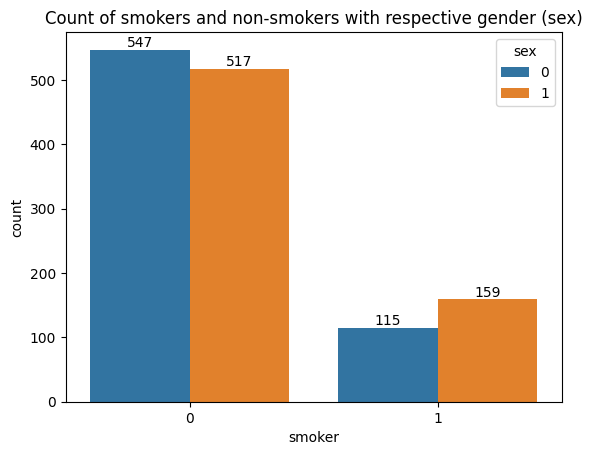

In [15]:
ax = sns.countplot(data=data , x='smoker' , hue='sex')
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
ax.set_title('Count of smokers and non-smokers with respective gender (sex)')
plt.show()

### Observation
* non-smoker patient are greater than smokers

## Charges for male and female with respective of smoking habit

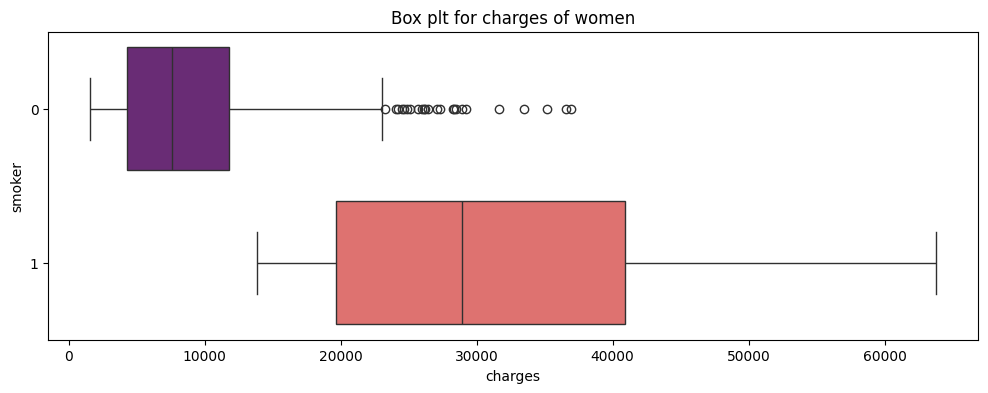

In [19]:
plt.figure(figsize=(12,4))
sns.boxplot(x='charges' , y='smoker' , data=data[data['sex']==0]  , orient='h' , palette='magma')
plt.title('Box plt for charges of women')
plt.show()

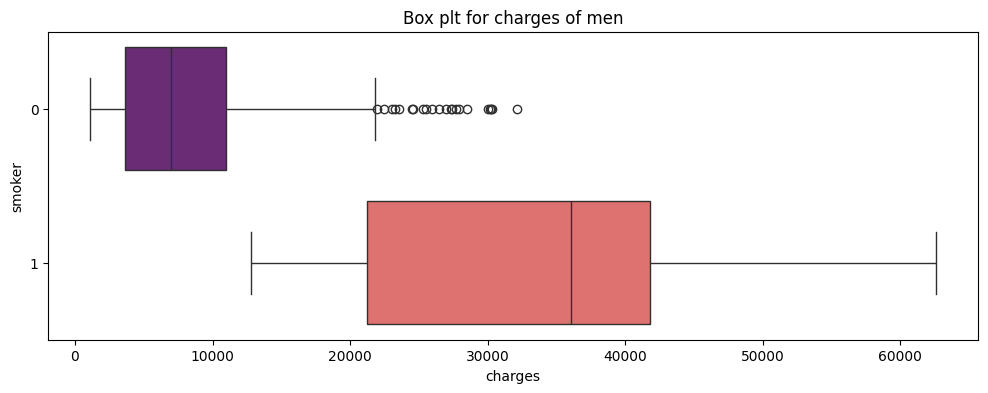

In [20]:
plt.figure(figsize=(12,4))
sns.boxplot(x='charges' , y='smoker' , data=data[data['sex']==1]  , orient='h' , palette='magma')
plt.title('Box plt for charges of men')
plt.show()

## Understanding age column

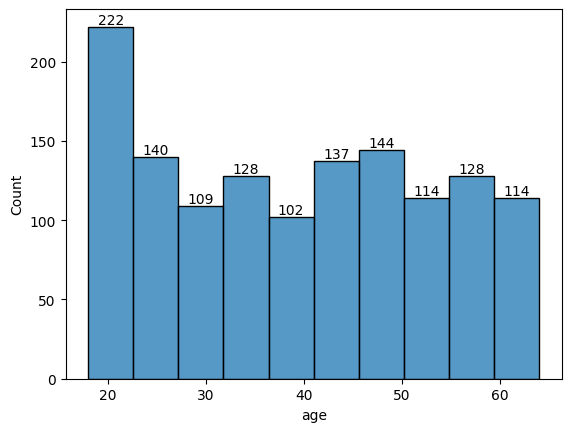

In [23]:
ax= sns.histplot(data['age'] ,bins=10)
ax.bar_label(ax.containers[0])
plt.show()

In [26]:
data[data['age'] <= 20]['age'].value_counts()

age
18    69
19    68
20    29
Name: count, dtype: int64

## Understanding the smoking habit of patient with age 18

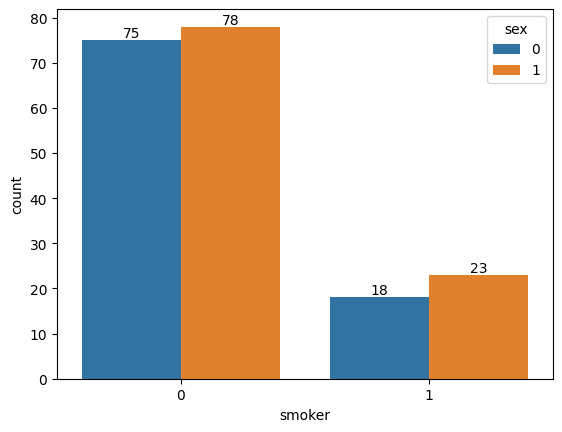

In [ ]:
ax = sns.countplot(x='smoker' , hue='sex' , data=data[data['age'] <= 21])
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.show()

### Does the smoking habit in young age has effect the patinet treatement cost (charges) ?

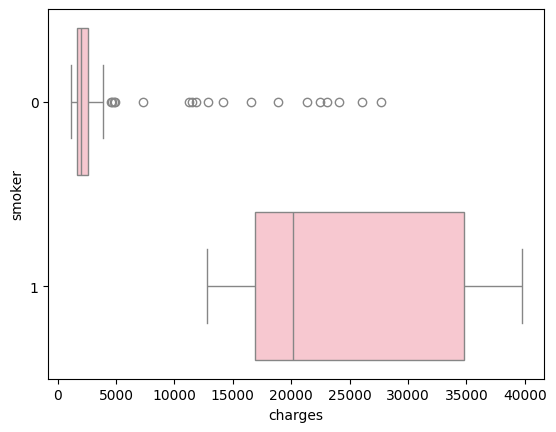

In [40]:
sns.boxplot(x='charges' , y='smoker' , data=data[data['age'] <= 21] , orient='h' , color='pink')
plt.show()

* Yes at young age treatement cost is higher if they smoke

## Understanding the smoking habit of patient with max age

In [34]:
data[data['age'] == data['age'].max()]['age'].value_counts()

age
64    22
Name: count, dtype: int64

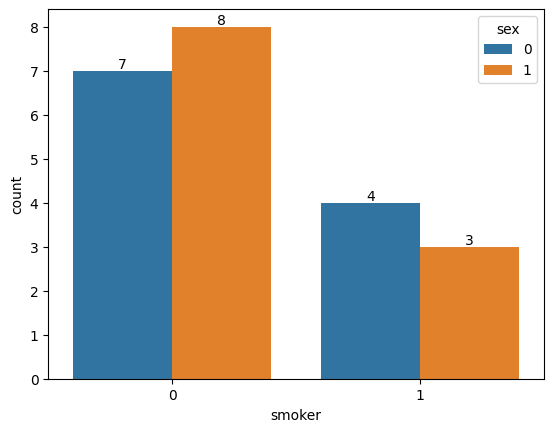

In [36]:
ax = sns.countplot(x='smoker' , hue='sex' , data=data[data['age'] == data['age'].max()])
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.show()

## Understanding age with resp to patinet treatement cost (charges)

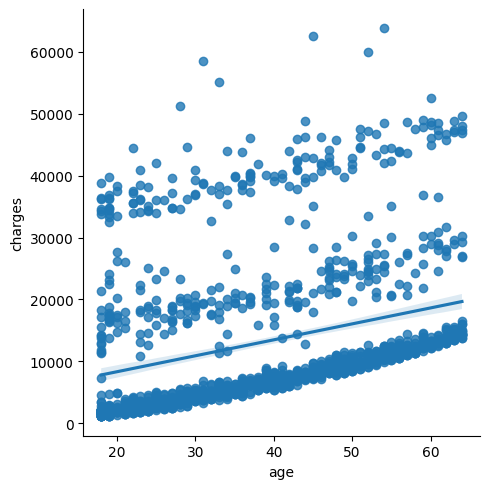

In [70]:
sns.lmplot(x='age', y='charges' ,data=data , height=5)
plt.show()

## smoker vs non-smoker charges

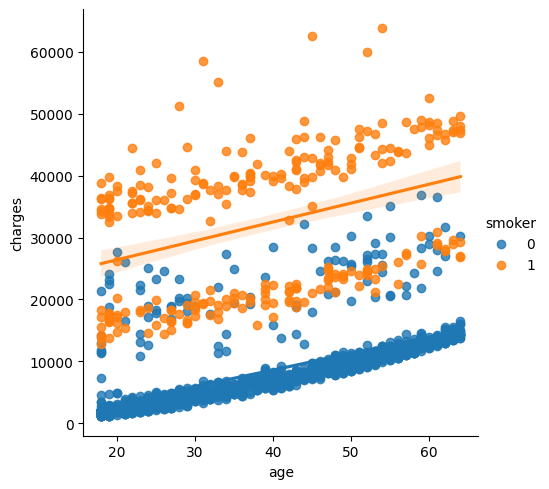

In [71]:
sns.lmplot(x='age', y='charges', hue='smoker' ,data=data , height=5)
plt.show()

## correleation of BMI with resp to charges and smoking habit

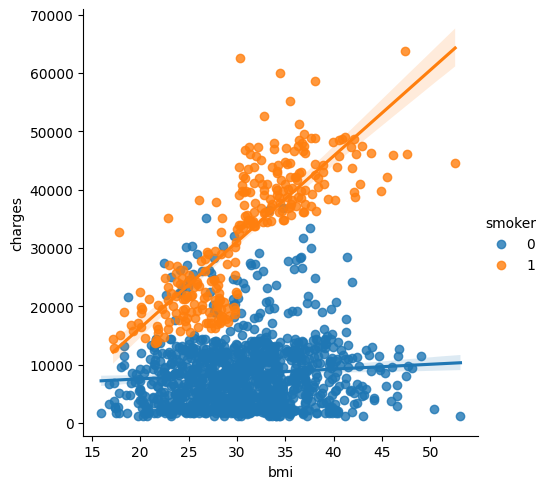

In [75]:
sns.lmplot(x='bmi', y='charges' ,hue='smoker',data=data , height=5)
plt.show()

In [73]:
data.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')